<a href="https://colab.research.google.com/github/avinashnaidu2131-gif/Alfido_Task-1/blob/main/Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Upload Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving zomato.csv to zomato.csv


**Install Required Libraries**

In [ ]:
!pip install plotly wordcloud

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt

**Load Dataset**

In [ ]:
df = pd.read_csv("zomato.csv")

**Data Cleaning**

In [ ]:
# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Fix rating
df = df[df['rate'].notnull()]
df = df[~df['rate'].isin(['NEW', '-'])]

df['rate'] = df['rate'].str.replace('/5', '')
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Fix cost
df['approx_cost(for_two_people)'] = df['approx_cost(for_two_people)'].astype(str)
df['approx_cost(for_two_people)'] = df['approx_cost(for_two_people)'].str.replace(',', '')
df['approx_cost(for_two_people)'] = pd.to_numeric(df['approx_cost(for_two_people)'], errors='coerce')

# Cuisine
df['cuisines'].fillna("Unknown", inplace=True)
df['main_cuisine'] = df['cuisines'].apply(lambda x: str(x).split(',')[0])

/tmp/ipykernel_8383/72184907.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cuisines'].fillna("Unknown", inplace=True)


**CREATE DASHBOARD UI**

In [ ]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Rating Distribution",
        "Top Cuisines",
        "Top Locations",
        "Price vs Rating"
    )
)

# 1. Ratings
fig.add_trace(
    go.Histogram(x=df['rate'], nbinsx=20),
    row=1, col=1
)

# 2. Top Cuisines
top_cuisines = df.groupby('main_cuisine')['rate'].mean().sort_values(ascending=False).head(10)

fig.add_trace(
    go.Bar(
        x=top_cuisines.values,
        y=top_cuisines.index,
        orientation='h'
    ),
    row=1, col=2
)

# 3. Locations
top_locations = df['location'].value_counts().head(10)

fig.add_trace(
    go.Bar(
        x=top_locations.index,
        y=top_locations.values
    ),
    row=2, col=1
)

# 4. Price vs Rating
fig.add_trace(
    go.Scatter(
        x=df['approx_cost(for_two_people)'],
        y=df['rate'],
        mode='markers'
    ),
    row=2, col=2
)

# Dashboard layout
fig.update_layout(
    height=800,
    width=1000,
    title_text="🍽️ Zomato Dashboard",
    template="plotly_white",
    showlegend=False
)

fig.show()

**Add KPI**

In [ ]:
print("⭐ Average Rating:", round(df['rate'].mean(),2))
print("🍽️ Total Restaurants:", df.shape[0])
print("📍 Locations:", df['location'].nunique())
print("🍜 Cuisines:", df['main_cuisine'].nunique())

⭐ Average Rating: 3.7
🍽️ Total Restaurants: 46137
📍 Locations: 2918
🍜 Cuisines: 2915


**HEATMAP**

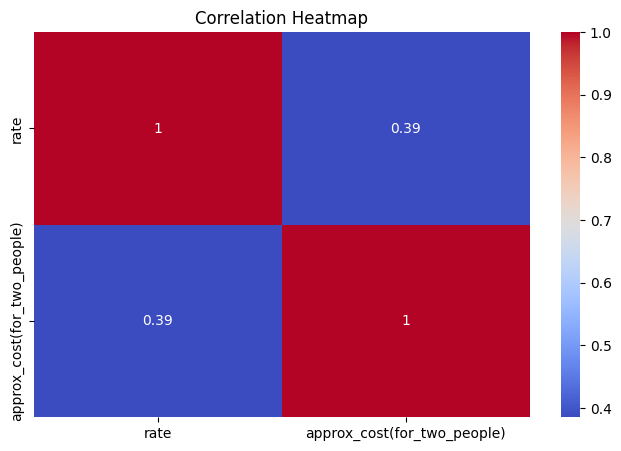

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

**WORD CLOUD**

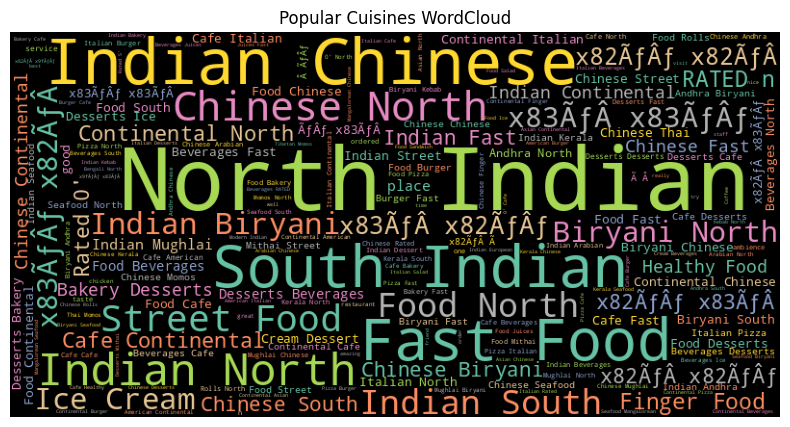

In [ ]:
from wordcloud import WordCloud

text = " ".join(df['cuisines'].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='black',
    colormap='Set2'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Popular Cuisines WordCloud")

plt.show()

### Key Insights
- Most restaurant ratings lie between 3.5 and 4.3
- Popular areas include BTM, Indiranagar, and Whitefield
- North Indian and Chinese cuisines dominate
- Higher price does not always mean higher rating


## Recommendations

1. Implement personalized restaurant recommendation system  
2. Promote affordable high-rated restaurants  
3. Focus on high-demand locations like BTM and Indiranagar  
4. Highlight trending cuisines such as North Indian and Chinese  
5. Improve visibility for new restaurants  